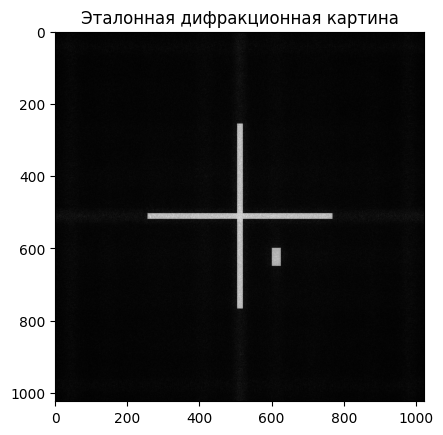

Otsu thresh param = 54.0
Otsu thresh param = 116.0
Матрица аффинного преобразования:
[[ 4.28283625e-01  2.00929499e-02 -1.82049790e+02]
 [-1.60583708e-02  4.27990492e-01 -2.96492384e+02]]


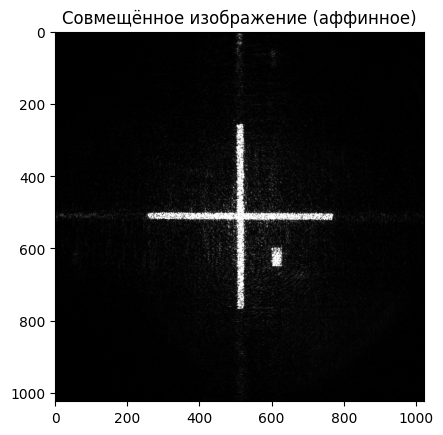

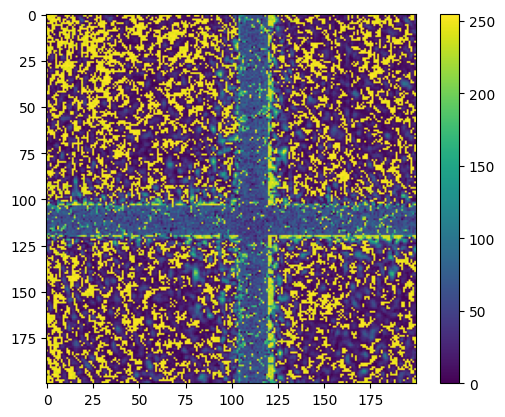

In [14]:
"""
ОБРАБОТКА ЭКСПЕРИМЕНТАЛЬНЫХ ДАННЫХ

Функция для расчёта коэффициентов наклона и сдвига для экспериментальных данных
(переписано с использованием PyTorch для вычисления дифракции)

Также обращаю внимание на следующие моменты. Можно использовать афинное преобразование (6 степеней свободы), а можно проективное - 8 степеней свободы.
Проблема в том, что для второго нужно 4 точки, но т.к. края изображения могут быть частично размыты спеклами, координаты плавают. 
Ошибка на 1-2 пикселя может сильно перекосить всё изображение.
Для афинного достаточно 3 точек + оно более устойчиво к шумам. С учётом преобразования 4096х3000 -> 256х256, его более чем хватит.

Так что разумно использовать афинное преобразование.
"""


"""
ОБРАБОТКА ЭКСПЕРИМЕНТАЛЬНЫХ ДАННЫХ
Совмещение эталонной и экспериментальной дифракционных картин
с помощью аффинного преобразования.
Исправлена функция find_cross_dimensions – теперь точки берутся из minAreaRect.
"""

import cv2
import numpy as np
import torch
import modulesDataSet as mds
from matplotlib import pyplot as plt

# Физические параметры
lam = 532e-9
z = 0.190
pixelsizeSLM = 8e-6



# Начальное поле
amplitude = np.ones((1024, 1024), dtype=np.float32)
phase = np.zeros((1024, 1024), dtype=np.float32)


def difraction(filepath):
    """
    Вычисляет дифракционную картину для фазовой маски.
    Возвращает numpy-массив uint8 (нормированная амплитуда).
    """
    doe = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    doe = doe / 255.0 * 2 * np.pi

    E0 = amplitude * np.exp(1j * (phase + doe))
    E0_tensor = torch.from_numpy(E0)

    if torch.cuda.is_available():
        E0_tensor = E0_tensor.cuda()

    propagated = mds.FresnelPropagator(E0_tensor, pixelsizeSLM, lam, z)
    difracted_tensor = mds.detectCamera(propagated)

    difracted = difracted_tensor.cpu().numpy() if torch.is_tensor(difracted_tensor) else difracted_tensor
    difracted = np.sqrt(difracted)
    difracted = (difracted / np.max(difracted) * 255).astype(np.uint8)

    return difracted


def find_cross_dimensions(image):
    """
    Находит параметры креста на изображении.
    Возвращает:
      width, height, angle,
      center_x, center_y,
      right_x, right_y,   # конец правого луча (по направлению width)
      top_x, top_y        # конец верхнего луча (по направлению height, перпендикулярно)
    """
    if image.dtype != np.uint8:
        image_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    else:
        image_8bit = image

    otsu_thresh, binary = cv2.threshold(image_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # 0 игнорируется,, порог по Отсу
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    print(f"Otsu thresh param = {otsu_thresh}")

    if not contours:
        return None, None, None, None, None, None, None, None, None

    contour = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(contour)
    box = cv2.boxPoints(rect).astype(np.int32)

    # Извлекаем параметры
    center = rect[0]                # (x, y) float
    width, height = rect[1]         # (w, h) float
    angle = rect[2]                 # угол в градусах (от -90 до 0)

    # Для визуализации – центр и размеры, но для аффинного преобразования используем эти же значения
    cx = int(center[0])
    cy = int(center[1])

    # Вычисляем координаты правого и верхнего концов с учётом угла
    # Угол в радианах
    ang_rad = np.deg2rad(angle)

    # Вектор вдоль первой стороны (ширина)
    vx = np.array([np.cos(ang_rad), np.sin(ang_rad)])
    # Вектор вдоль второй стороны (высота) – перпендикулярен первой
    vy = np.array([-np.sin(ang_rad), np.cos(ang_rad)])

    # Координаты концов (в пикселях)
    right_x = int(cx + 0.5 * width * vx[0])
    right_y = int(cy + 0.5 * width * vx[1])
    top_x = int(cx + 0.5 * height * vy[0])
    top_y = int(cy + 0.5 * height * vy[1])

    # Визуализация (для отладки)
    result = cv2.cvtColor(image_8bit, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(result, [box], 0, (0, 255, 0), 2)
    # Рисуем оси
    cv2.line(result, (cx, cy), (right_x, right_y), (255, 0, 0), 2)  # красный – правая ось
    cv2.line(result, (cx, cy), (top_x, top_y), (0, 0, 255), 2)      # синий – верхняя ось
    cv2.putText(result, f'Angle: {angle:.2f} deg', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(result, f'Width: {int(width)} px', (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(result, f'Height: {int(height)} px', (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    return (width, height, angle,
            cx, cy,
            right_x, right_y,
            top_x, top_y,
            result)   # добавили result для отображения


def apply_affine_transform(image, M, center_x_ok, center_y_ok):
    """
    Применяет аффинное преобразование к изображению и вырезает
    область 1024x1024 вокруг точки (center_x_ok, center_y_ok).
    """
    h, w = image.shape[:2]
    aligned = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    half = 512
    x1 = center_x_ok - half
    x2 = center_x_ok + half
    y1 = center_y_ok - half
    y2 = center_y_ok + half

    if x1 < 0 or y1 < 0 or x2 > w or y2 > h:
        cropped = np.zeros((1024, 1024), dtype=aligned.dtype)
        src_x1 = max(0, x1)
        src_y1 = max(0, y1)
        src_x2 = min(w, x2)
        src_y2 = min(h, y2)
        dst_x1 = src_x1 - x1
        dst_y1 = src_y1 - y1
        dst_x2 = src_x2 - x1
        dst_y2 = src_y2 - y1
        cropped[dst_y1:dst_y2, dst_x1:dst_x2] = aligned[src_y1:src_y2, src_x1:src_x2]
    else:
        cropped = aligned[y1:y2, x1:x2]

    return cropped


# ---- 1. Генерируем эталонное изображение ----
difracted = difraction(
    'C:/Users/thatm/VSCodeProjects/Old (Zernike + GS)/Experimental complex done/DATA/masks_for_gs/holo_cross_0.19.png'
)
plt.imshow(difracted, cmap='gray')
plt.title("Эталонная дифракционная картина")
plt.show()

# ---- 2. Загружаем экспериментальное изображение ----
image = cv2.imread(
    'C:/Users/thatm/VSCodeProjects/Old (Zernike + GS)/Experimental complex done/DATA/captured_raw/L19_ap448_mask256/cross.png',
    cv2.IMREAD_GRAYSCALE
)
image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
image = cv2.flip(image, 1)

# ---- 3. Находим параметры крестов ----
res_ok = find_cross_dimensions(difracted)
res_exp = find_cross_dimensions(image)

if None in (res_ok, res_exp):
    raise ValueError("Не удалось найти крест на одном из изображений")

(w_ok, h_ok, ang_ok, cx_ok, cy_ok, rx_ok, ry_ok, tx_ok, ty_ok, vis_ok) = res_ok
(w_exp, h_exp, ang_exp, cx_exp, cy_exp, rx_exp, ry_exp, tx_exp, ty_exp, vis_exp) = res_exp

# Показываем визуализацию для отладки -------------------------------------------------------------------------------------------
cv2.imshow("Эталон с осями", vis_ok)
#cv2.imshow("Эксперимент с осями", vis_exp)

cv2.namedWindow('Эксперимент с осями', cv2.WINDOW_NORMAL)  
cv2.resizeWindow('Эксперимент с осями', 750, 1024)          
cv2.imshow('Эксперимент с осями', vis_exp)

#cv2.waitKey(0) # ----------------------------------------------РАСКОММЕНТИРОВАТЬ ДЛЯ ОТЛАДКИ
cv2.destroyAllWindows()

# ---- 4. Строим матрицу аффинного преобразования по трём точкам ----
src_pts = np.float32([
    [cx_exp, cy_exp],
    [rx_exp, ry_exp],
    [tx_exp, ty_exp]
])
dst_pts = np.float32([
    [cx_ok, cy_ok],
    [rx_ok, ry_ok],
    [tx_ok, ty_ok]
])

M = cv2.getAffineTransform(src_pts, dst_pts)
print(f"Матрица аффинного преобразования:\n{M}")

# ---- 5. Преобразуем исходное изображение и вырезаем область ----
aligned_cropped = apply_affine_transform(image, M, cx_ok, cy_ok)

plt.imshow(aligned_cropped, cmap='gray')
plt.title("Совмещённое изображение (аффинное)")
plt.show()

# ---- 6. Сохраняем уменьшенную копию 256x256 для модели ----
def save_normalized_1024_to_256(image, filename):
    if image.dtype != np.uint8:
        img_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    else:
        img_8bit = image
    if len(img_8bit.shape) == 3:
        gray = cv2.cvtColor(img_8bit, cv2.COLOR_RGB2GRAY)
    else:
        gray = img_8bit
    cv2.imwrite(filename, cv2.resize(gray, (256, 256)))

save_normalized_1024_to_256(aligned_cropped, "aligned_cross_256.png")

# ---- 7. Функция для применения тех же преобразований к другим кадрам ----
def transform_any(image, M, cx_ok, cy_ok):
    return apply_affine_transform(image, M, cx_ok, cy_ok)

plt.imshow(aligned_cropped[400:600, 400:600] - difracted[400:600, 400:600])
plt.colorbar()
plt.show()

In [ ]:
def combine(filepath_half):
  #Расчёт трехканального изображения дифракции в эксперименте
  img_array = np.zeros((256, 256, 3), dtype=np.uint8)
  
  for k in range(3):
    image = cv2.imread(filepath_half + str(k+1) + '_06_sized.png', cv2.IMREAD_GRAYSCALE)  
    image = image/np.max(image) * 255

    img_array[..., k] = image  # k-й канал

  return img_array

filepath_half = 'C:/Users/thatm/VSCodeProjects/experiment/data/'
combined = combine(filepath_half)

Image.fromarray(combined).save(f'C:/Users/thatm/VSCodeProjects/experiment/data/norm06.png')